18) 탐색 - 정형 데이터 시각화 : 탐색 목적에 따라 1

3. 탐색 목적에 따른 분류
예시 <br>
분포 → 학생의 수학점수 하나만으로 히스토그램 가능 → 일변량 <br>
비교 → 지역별 매출 → 다변량 <br>
관계 → 공부시간 ↔ 점수 → 다변량 <br>
시간 → 날짜 + 매출 → 사실상 시간변수와 측정변수가 필요 → 다변량으로 보는 게 일반적 <br>
공간 → 지역 + 인구 → 공간정보와 측정값이 필요 → 다변량으로 보는 게 일반적 <br>

비교 시각화
- "무엇이 더 큰가?"
- "집단 간 차이가 있는가?"

주요 차트
- 막대그래프 
- 그룹 막대그래프 
- 누적 막대그래프 
- 100% 누적 막대그래프 
- Boxplot

- 그룹 막대 <br>
성별 × 시험 → 평균 점수 비교 <br>

- 누적 막대 <br>
성별 x 반별 → 학생 구성 비교 <br>

- 범주별 Boxplot <br>
성별 × 점수 → 집단별 분포 비교 <br>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# 차트에 한글 깨지지 않도록 차트 폰트변경
plt.rcParams['font.family'] = 'Malgun Gothic'
# 차트에 "-"문자 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.DataFrame({
    "이름": ["김철수", "이영희", "박민수", "최지영"],
    "성별": ["남", "여", "남", "여"],
    "중간고사": [78, 82, 85, 90],
    "기말고사": [84, 88, 80, 92]
})
df


,이름,성별,중간고사,기말고사
0,김철수,남,78,84
1,이영희,여,82,88
2,박민수,남,85,80
3,최지영,여,90,92


* 시각화 전에 데이터 전처리/분석 등을 먼저 선행 되는 경우가 많다. 전처리나 분석방법은 뒤에서 학습한다.

In [3]:
# 전처리 
result = df.groupby("성별")[["중간고사", "기말고사"]].mean()
result

,중간고사,기말고사
성별,,
남,81.5,82.0
여,86.0,90.0


In [4]:
# 전처리가 필요 남-> 평균, 여 -> 평균
"""
select 설명, avg(중간고사), avg(기말고사) 
from df 
group by 성별
의 과정과 동일하다.
"""
result = df.groupby("성별")[["중간고사", "기말고사"]].mean()
result

,중간고사,기말고사
성별,,
남,81.5,82.0
여,86.0,90.0


1) 그룹 막대 그래프



<Axes: xlabel='성별'>

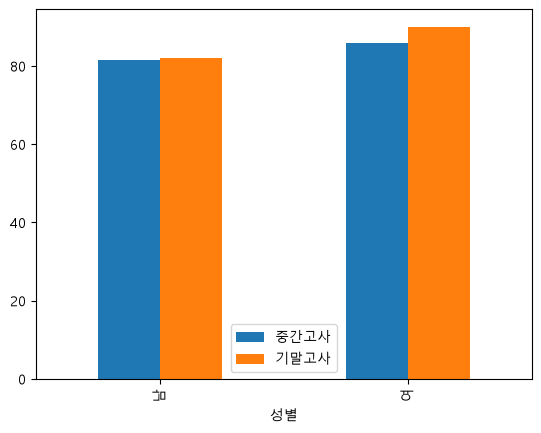

In [4]:
# stacked=False 생략하여도 False로 그룹막대 차트
# stacked=False 이면 누적막대 차트 
result.plot(kind="bar", stacked=False)

2) 누적 막대 그래프

<Axes: xlabel='성별'>

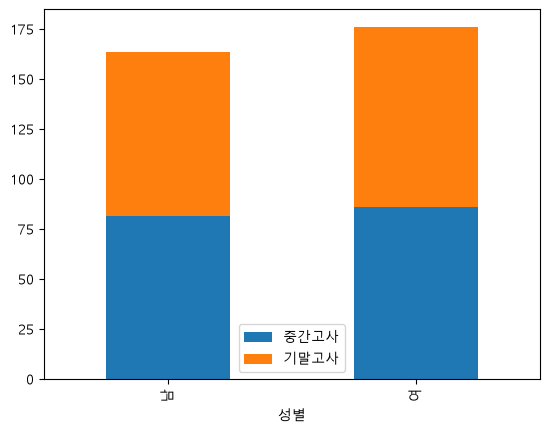

In [ ]:
result.plot(kind="bar", stacked=True) # True이면 누적막대 차트

In [5]:
import pandas as pd

data = {
    "이름": ["김민수", "이영희", "박철수", "최지우", "정민호",
           "한지민", "강준호", "윤서연", "오세훈", "임수진",
           "장현우", "김하늘", "이준혁", "박서윤", "최민재",
           "정유진", "한승우", "윤지아", "강민호", "송예린"],
    
    "성별": ["남", "여", "남", "여", "남",
           "여", "남", "여", "남", "여",
           "남", "여", "남", "여", "남",
           "여", "남", "여", "남", "여"],
    
    "반": ["1반", "1반", "1반", "2반", "2반",
         "2반", "3반", "3반", "3반", "1반",
         "1반", "2반", "2반", "3반", "3반",
         "1반", "1반", "2반", "2반", "3반"]
}

df = pd.DataFrame(data)

df

,이름,성별,반
0,김민수,남,1반
1,이영희,여,1반
2,박철수,남,1반
3,최지우,여,2반
4,정민호,남,2반
5,한지민,여,2반
6,강준호,남,3반
7,윤서연,여,3반
8,오세훈,남,3반
9,임수진,여,1반


In [6]:
# 데이터 확인
display(df.head())

,이름,성별,반
0,김민수,남,1반
1,이영희,여,1반
2,박철수,남,1반
3,최지우,여,2반
4,정민호,남,2반


In [7]:
# 행과 열 확인
print(df.shape)

(20, 3)


In [9]:
result = df.groupby(["성별", "반"]).size()
 # size()는 결측치도 포함, count()는 결측치는 카운팅X

print(result)

성별  반 
남   1반    4
    2반    3
    3반    3
여   1반    3
    2반    4
    3반    3
dtype: int64


In [10]:
# "성별·반별 학생 수를 집계한 후, unstack()으로 반을 컬럼으로 펼쳐 시각화하기 좋은 형태로 만든다."
result2 = result.unstack() # df.groupby(["성별", "반"]).size().unstack()
print(result2)

반   1반  2반  3반
성별            
남    4   3   3
여    3   4   3


<Axes: xlabel='성별'>

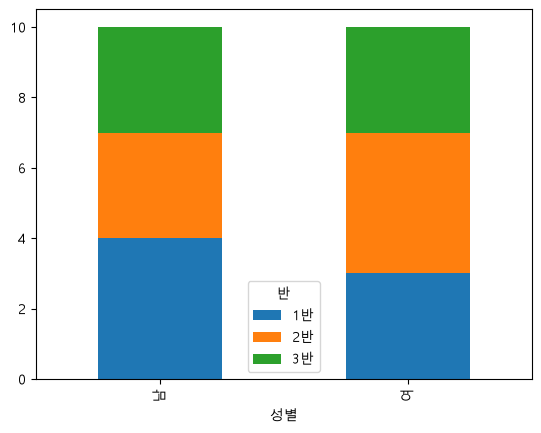

In [11]:
# stacked=False 이면 누적막대 차트 
# stacked=False (생략하면 기본값 False) 그룹막대 차트
result2.plot(kind="bar", stacked=True)

In [9]:
# --------------------------------------------------
# 학생 성적 데이터 생성
# --------------------------------------------------

data = {
    "이름": [
        "김민준", "이서연", "박지훈", "최지우", "정도윤",
        "강서준", "윤하은", "장현우", "임수빈", "한지민",
        "오준호", "서유진", "신건우", "권예은", "황민재",
        "송채원", "조현준", "배수아", "문지호", "류다은",
        "김도현", "이하윤", "박시우", "최유나", "정우진",
        "강예린", "윤준서", "장서윤", "임도현", "한유진"
    ],

    "성별": [
        "남", "여", "남", "여", "남",
        "남", "여", "남", "여", "여",
        "남", "여", "남", "여", "남",
        "여", "남", "여", "남", "여",
        "남", "여", "남", "여", "남",
        "여", "남", "여", "남", "여"
    ],

    "반": [
        "A", "A", "A", "A", "A",
        "B", "B", "B", "B", "B",
        "A", "A", "A", "A", "A",
        "B", "B", "B", "B", "B",
        "A", "A", "A", "A", "A",
        "B", "B", "B", "B", "B"
    ],

    "학년": [
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        2, 2, 2, 2, 2,
        2, 2, 2, 2, 2,
        3, 3, 3, 3, 3,
        3, 3, 3, 3, 3
    ],

    "중간고사": [
        70, 82, 65, 90, 75,
        88, 72, 80, 95, 68,
        78, 85, 70, 92, 81,
        75, 89, 94, 73, 86,
        83, 91, 77, 96, 72,
        88, 79, 93, 85, 90
    ],

    "기말고사": [
        75, 85, 70, 88, 78,
        92, 76, 84, 97, 73,
        82, 88, 75, 95, 85,
        80, 91, 96, 78, 90,
        87, 94, 81, 98, 76,
        92, 83, 95, 89, 93
    ]
}

df = pd.DataFrame(data)
df

,이름,성별,반,학년,중간고사,기말고사
0,김민준,남,A,1,70,75
1,이서연,여,A,1,82,85
2,박지훈,남,A,1,65,70
3,최지우,여,A,1,90,88
4,정도윤,남,A,1,75,78
5,강서준,남,B,1,88,92
6,윤하은,여,B,1,72,76
7,장현우,남,B,1,80,84
8,임수빈,여,B,1,95,97
9,한지민,여,B,1,68,73


In [10]:
# 데이터 확인
display(df.head())

,이름,성별,반,학년,중간고사,기말고사
0,김민준,남,A,1,70,75
1,이서연,여,A,1,82,85
2,박지훈,남,A,1,65,70
3,최지우,여,A,1,90,88
4,정도윤,남,A,1,75,78


In [11]:
# 행과 열 확인
print(df.shape)

(30, 6)


<Axes: title={'center': '중간고사'}, xlabel='성별'>

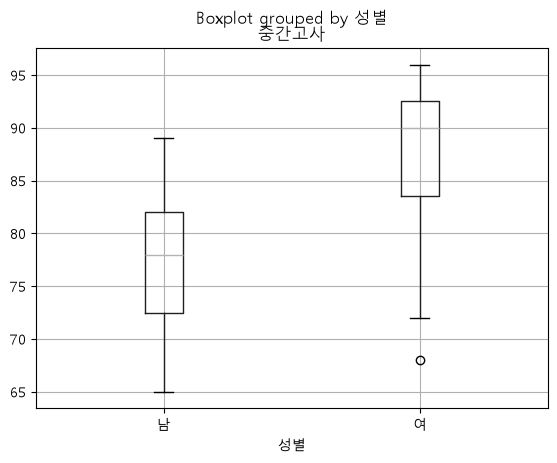

In [12]:
# 남녀 학생의 중간고사 점수 분포 비교
df.boxplot(column="중간고사", by="성별")

4) 두개의 수치형 변수를 비교

<Axes: >

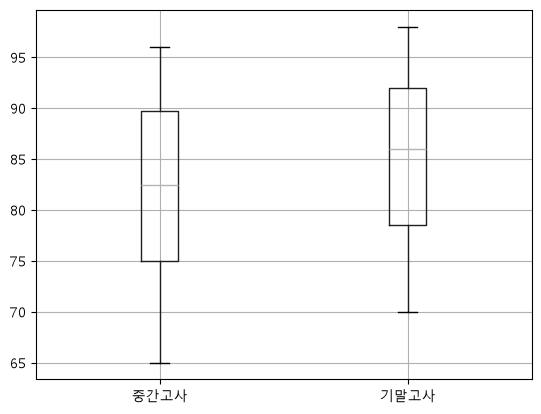

In [13]:
df.boxplot(column=["중간고사", "기말고사"])

array([<Axes: title={'center': '중간고사'}, xlabel='성별'>,
       <Axes: title={'center': '기말고사'}, xlabel='성별'>], dtype=object)

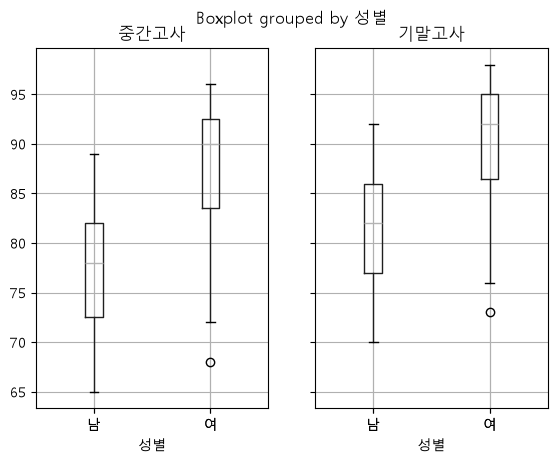

In [16]:
df.boxplot(column=["중간고사", "기말고사"], by="성별")

분포 시각화 <br>
"데이터가 어떻게 퍼져 있는가?" <br>

​단순히 평균만 보는 것이 아니라 <br>
- 어디에 데이터가 몰려 있는가? 
- 퍼져 있는 정도는? 
- 좌우로 치우쳤는가? 
- 이상치는 있는가? <br>
를 본다.

주요 차트 <br>
- 히스토그램 
- Boxplot 
- KDE 
- Violin plot 
- Strip plot

중간/기말 성적의 분포를 비교

In [14]:
import pandas as pd

data = {
    "중간고사": [
        61, 64, 65, 66, 67, 68, 69, 70, 70, 71,
        72, 72, 73, 74, 74, 75, 75, 76, 76, 77,
        77, 78, 78, 79, 79, 80, 80, 81, 81, 82,
        82, 83, 83, 84, 84, 85, 85, 86, 87, 87,
        88, 88, 89, 90, 91, 92, 93, 94, 96, 98
    ],

    "기말고사": [
        64, 66, 67, 68, 69, 70, 71, 72, 72, 73,
        74, 74, 75, 76, 76, 77, 78, 78, 79, 80,
        80, 81, 81, 82, 82, 83, 83, 84, 84, 85,
        85, 86, 86, 87, 87, 88, 88, 89, 90, 90,
        91, 92, 93, 94, 95, 96, 97, 98, 99, 100
    ]
}

df = pd.DataFrame(data)
df

,중간고사,기말고사
0,61,64
1,64,66
2,65,67
3,66,68
4,67,69
5,68,70
6,69,71
7,70,72
8,70,72
9,71,73


array([<Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>],
      dtype=object)

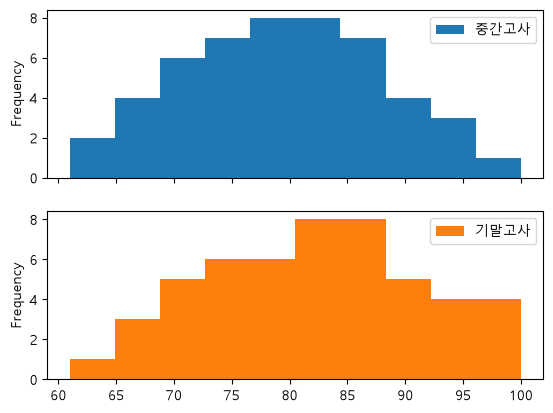

In [ ]:
# 각각
df[["중간고사", "기말고사"]].plot(
    kind="hist",
    bins=10,
    subplots=True
)

<Axes: ylabel='Frequency'>

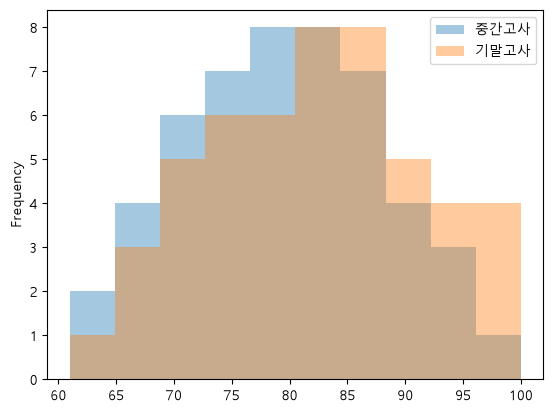

In [19]:
# 겹쳐서
df[["중간고사", "기말고사"]].plot(
    kind="hist",
    bins=10,
    alpha=0.4
)


관계 시각화 <br>
"변수와 변수 사이에 관계가 있는가?" <br>
<br>
공부시간 ↔ 시험점수 <br>
광고비 ↔ 매출 <br>
키 ↔ 몸무게 <br>


주요 차트 <br>
- 산점도 
- 버블차트 
- 상관관계 히트맵 
- Pair plot 
- 평행좌표

In [16]:
import pandas as pd

data = {
    "이름": [f"학생{i}" for i in range(1, 31)],

    # 공부시간이 많을수록 시험점수가 높아지는 관계
    "공부시간": [
        1, 1, 2, 2, 2, 3, 3, 3, 4, 4,
        4, 5, 5, 5, 6, 6, 6, 7, 7, 7,
        8, 8, 8, 9, 9, 9, 10, 10, 10, 11
    ],

    # 공부시간이 많을수록 게임시간이 줄어드는 관계
    "게임시간": [
        5.5, 5.0, 5.2, 4.7, 4.5, 4.3, 4.0, 3.8, 3.7, 3.5,
        3.3, 3.0, 2.9, 2.7, 2.5, 2.3, 2.2, 2.0, 1.8, 1.7,
        1.5, 1.4, 1.2, 1.1, 1.0, 0.9, 0.7, 0.6, 0.5, 0.3
    ],

    # 공부시간과 특별한 관계가 없도록 만든 변수
    "키": [
        158, 172, 165, 180, 163, 175, 169, 161, 178, 166,
        182, 159, 171, 168, 176, 164, 181, 160, 173, 167,
        179, 162, 170, 177, 165, 183, 169, 174, 161, 178
    ],

    # 공부시간이 증가할수록 대체로 점수가 증가
    "시험점수": [
        52, 55, 58, 60, 61, 64, 66, 65, 69, 71,
        73, 74, 76, 78, 79, 81, 80, 84, 86, 85,
        87, 89, 88, 91, 92, 90, 94, 95, 96, 98
    ]
}

df = pd.DataFrame(data)

df

,이름,공부시간,게임시간,키,시험점수
0,학생1,1,5.5,158,52
1,학생2,1,5.0,172,55
2,학생3,2,5.2,165,58
3,학생4,2,4.7,180,60
4,학생5,2,4.5,163,61
5,학생6,3,4.3,175,64
6,학생7,3,4.0,169,66
7,학생8,3,3.8,161,65
8,학생9,4,3.7,178,69
9,학생10,4,3.5,166,71


양의 상관관계 <br>
공부시간 ↔ 시험점수 <br>
공부시간이 증가할수록 시험점수가 증가하는 경향이 있다.

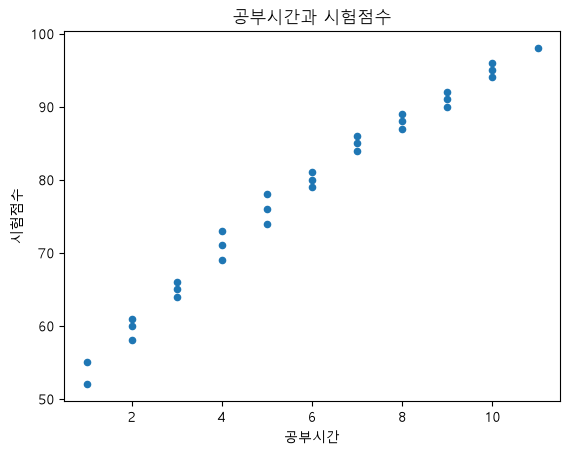

In [21]:
df.plot(
    kind="scatter",
    x="공부시간",
    y="시험점수"
)

plt.title("공부시간과 시험점수")
plt.xlabel("공부시간")
plt.ylabel("시험점수")
plt.show()

음의 상관관계 <br>
게임시간 ↔ 시험점수 <br>
게임시간이 증가할수록 시험점수가 감소하는 경향이 있다.

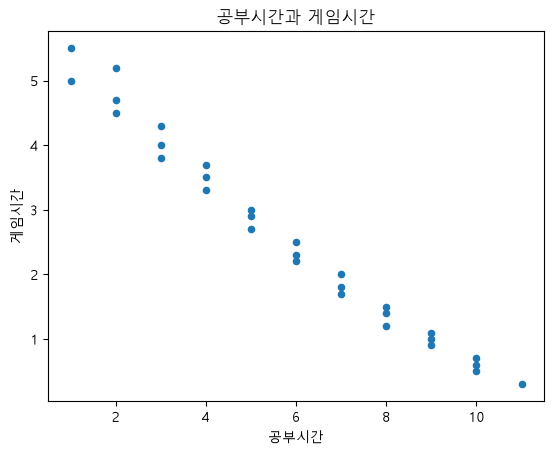

In [22]:
df.plot(
    kind="scatter",
    x="공부시간",
    y="게임시간"
)

plt.title("공부시간과 게임시간")
plt.xlabel("공부시간")
plt.ylabel("게임시간")
plt.show()

관계가 없는 경우 <br>
공부시간 ↔ 키 <br>
공부시간과 키 사이에 뚜렷한 선형 관계가 보이지 않는다.

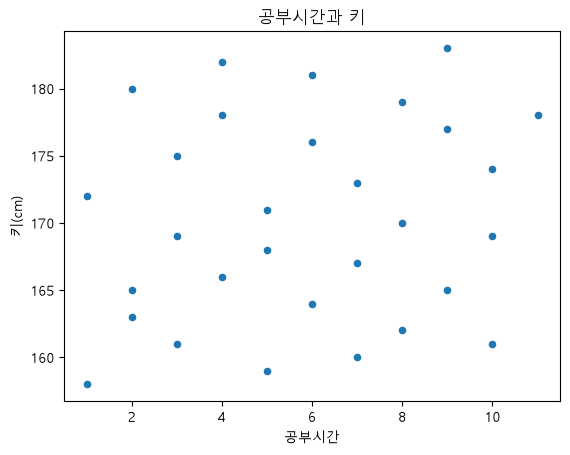

In [23]:
df.plot(
    kind="scatter",
    x="공부시간",
    y="키"
)

plt.title("공부시간과 키")
plt.xlabel("공부시간")
plt.ylabel("키(cm)")
plt.show()

여기서 "상관관계가 있다 = 원인과 결과가 있다"는 의미는 아니다. <br>
차트로 관계를 먼저 탐색 → 통계량으로 관계를 수치화하여 확인 <br>
이 데이터셋은 산점도 → 상관계수(corr()) → 양/음/무상관 해석

corr()의 의미

- corr()는 기본적으로 피어슨 상관계수(Pearson correlation coefficient)​를 계산한다.

In [24]:
print("공부시간 ↔ 시험점수:", df["공부시간"].corr(df["시험점수"]))

print("공부시간 ↔ 게임시간:", df["공부시간"].corr(df["게임시간"]))

print("공부시간 ↔ 키:", df["공부시간"].corr(df["키"]))

공부시간 ↔ 시험점수: 0.9894987139885268
공부시간 ↔ 게임시간: -0.9889955723429229
공부시간 ↔ 키: 0.16579121084332799


20) 탐색 - 정형 데이터 시각화 : 탐색 목적에 따라 3

시간 시각화 <br>
"시간이 지나면서 어떻게 변하는가?" <br>
"추세, 증가/감소, 계절성, 주기성, 변동을 확인" <br>

주요 차트 
- 선그래프 
- 영역그래프 
- 누적 영역그래프 
- 시계열 차트

In [18]:
data = {
    "날짜": [
        "2026-01-01", "2026-01-02", "2026-01-03", "2026-01-04", "2026-01-05",
        "2026-01-06", "2026-01-07", "2026-01-08", "2026-01-09", "2026-01-10",
        "2026-01-11", "2026-01-12", "2026-01-13", "2026-01-14", "2026-01-15"
    ],
    "판매량": [
        20, 25, 22, 30, 28,
        35, 32, 40, 38, 45,
        42, 48, 50, 46, 55
    ],
    "매출액": [
        200, 250, 220, 300, 280,
        350, 320, 400, 380, 450,
        420, 480, 500, 460, 550
    ],
    "순이익": [
        40, 50, 44, 60, 56,
        70, 64, 80, 76, 90,
        84, 96, 100, 92, 110
    ]
}

df = pd.DataFrame(data)
df

,날짜,판매량,매출액,순이익
0,2026-01-01,20,200,40
1,2026-01-02,25,250,50
2,2026-01-03,22,220,44
3,2026-01-04,30,300,60
4,2026-01-05,28,280,56
5,2026-01-06,35,350,70
6,2026-01-07,32,320,64
7,2026-01-08,40,400,80
8,2026-01-09,38,380,76
9,2026-01-10,45,450,90


In [19]:
df.head()

,날짜,판매량,매출액,순이익
0,2026-01-01,20,200,40
1,2026-01-02,25,250,50
2,2026-01-03,22,220,44
3,2026-01-04,30,300,60
4,2026-01-05,28,280,56


In [20]:
# 시계열 데이터에서는 날짜를 문자열로 두지 않고 datetime으로 변환
df["날짜"] = pd.to_datetime(df["날짜"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   날짜      15 non-null     datetime64[us]
 1   판매량     15 non-null     int64         
 2   매출액     15 non-null     int64         
 3   순이익     15 non-null     int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 612.0 bytes


<Axes: title={'center': '날짜별 판매량'}, xlabel='날짜'>

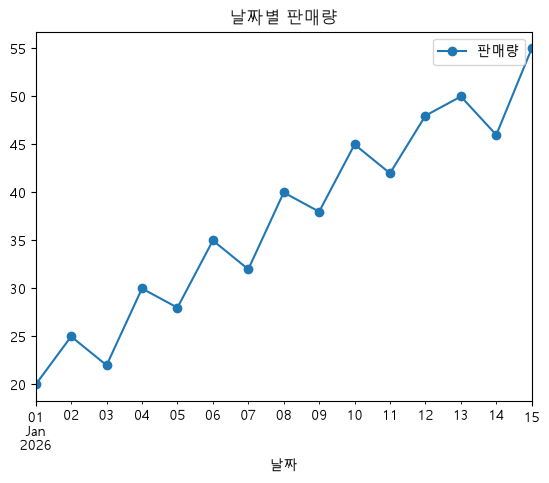

In [21]:
df.plot(
    x="날짜",
    y="판매량",
    kind="line",
    marker="o",
    title="날짜별 판매량"
)

<Axes: title={'center': '날짜별 매출액과 순이익'}, xlabel='날짜'>

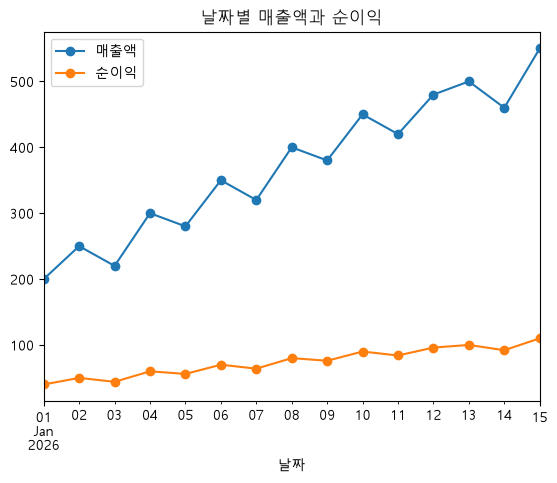

In [22]:
# 매출액 + 순이익
df.plot(
    x="날짜",
    y=["매출액", "순이익"],
    kind="line",
    marker="o",
    title="날짜별 매출액과 순이익"
)

공간 시각화
"지역에 따라 어떻게 다른가?" <br>
지역별 인구 → 지도 위에 지역별 인구 크기를 표현 <br>
지하철역별 승하차 인원 → 역의 위치에 원의 크기를 표현 <br>

주요 시각화
- 단계구분도(Choropleth) : 색으로 표현
- 버블맵 : 원의 크기로 표현, 특정 위치에 원을 그리고 값이 클수록 원을 크게
- 점 지도 : 점이 모여 있으면 해당 지역에 데이터가 많이 분포
- 등치선도 : 선으로 표현, 값이 같은 지점을 선으로 연결
- 카토그램 : 지역의 크기를 변형, 카토그램은 지역의 실제 크기나 모양을 데이터에 따라 변형한다.

In [ ]:
# 데이터 준비
data = {
    "역": [
        "강남역", "홍대입구역", "서울역", "잠실역", "역삼역",
        "신촌역", "건대입구역", "사당역", "종로3가역", "고속터미널역"
    ],
    "위도": [
        37.4979, 37.5572, 37.5547, 37.5133, 37.5006,
        37.5551, 37.5404, 37.4766, 37.5712, 37.5048
    ],
    "경도": [
        127.0276, 126.9245, 126.9707, 127.1000, 127.0366,
        126.9368, 127.0692, 126.9816, 126.9918, 127.0049
    ],
    "승하차인원": [
        180000, 150000, 140000, 125000, 110000,
        95000, 90000, 85000, 80000, 75000
    ]
}

station_df = pd.DataFrame(data)

station_df

,역,위도,경도,승하차인원
0,강남역,37.4979,127.0276,180000
1,홍대입구역,37.5572,126.9245,150000
2,서울역,37.5547,126.9707,140000
3,잠실역,37.5133,127.1000,125000
4,역삼역,37.5006,127.0366,110000
5,신촌역,37.5551,126.9368,95000
6,건대입구역,37.5404,127.0692,90000
7,사당역,37.4766,126.9816,85000
8,종로3가역,37.5712,126.9918,80000
9,고속터미널역,37.5048,127.0049,75000


In [24]:
# 지도 시각화를 위한 folium 라이브러리 불러오기
import folium

# 대한민국 서울을 중심으로 기본 지도 만들기
m = folium.Map(
    location=[37.55, 126.98],   # 지도 중심 위치: 위도, 경도
    zoom_start=11               # 지도의 확대 정도
)

In [25]:
# 지하철역 데이터를 한 행씩 반복
for i in range(len(station_df)):

    # 현재 행의 데이터를 row에 저장
    row = station_df.iloc[i]

    # 지도에 원(버블) 표시
    folium.CircleMarker(
        location=[
            row["위도"],          # 원을 표시할 위치의 위도
            row["경도"]           # 원을 표시할 위치의 경도
        ],

        # 승하차 인원이 많을수록 원을 크게 표시
        radius=row["승하차인원"] / 10000,

        # 원을 클릭하면 역 이름과 승하차 인원 표시
        popup=f'{row["역"]}: {row["승하차인원"]:,}명',

        # 원 내부를 채우기
        fill=True

    # 만든 원을 지도에 추가
    ).add_to(m)


# 완성된 지도를 HTML 파일로 저장
m.save("subway_map.html")

# 저장이 완료되었다는 메시지 출력
print("지도 저장 완료")

지도 저장 완료
